# Import des bibliothèques nécessaires

In [1]:
import pandas as pd
import pathlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import gensim
from collections import defaultdict
from gensim import corpora
import re
from gensim.models import LdaModel
import spacy
from spacy.tokenizer import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from pathlib import Path
import sys
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Chargement du modèle de langue français de spaCy

In [2]:
nlp = spacy.load("fr_core_news_lg")
nlp_trf = spacy.load("fr_dep_news_trf")

/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dossier_path = Path("/Users/morganr/Champs_lexicaux_N-A/corpus_goncourt")

donnees = []

# On boucle sur tous les fichiers .txt du dossier
for fichier in dossier_path.glob("*.txt"):
    with open(fichier, "r", encoding="utf-8") as f:
        contenu = f.read()
        
        # On détermine le label selon le nom du fichier
    donnees.append({
            "nom_fichier": fichier.name,
            "texte_brut": contenu,
        })
      
         

# Création du tableau de bord (DataFrame)
df = pd.DataFrame(donnees)
print(f"{len(df)} textes chargés avec succès.")

df

10 textes chargés avec succès.


,nom_fichier,texte_brut
0,1869_madame_gervaisais_travail.txt,"— Quarante scudi ?\n— Oui, signora.\n— Cela fa..."
1,1884_cherie_travail.txt,"petites amies à peu près de son âge, des place..."
2,1861_sœur_philomène_travail.txt,"La salle est haute et vaste. Elle est longue, ..."
3,1879_frères_zemganno_travail.txt,"En pleine campagne, au pied d’un poteau d’octr..."
4,1877_la_fille_elisa_travail.txt,"La femme, la prostituée condamnée à mort, étai..."
5,1865_germinie_lacerteux_travail.txt,"— Sauvée ! vous voilà donc sauvée, mademoisell..."
6,1867_manette_salomon_travail.txt,On était au commencement de novembre. La derni...
7,1860_Charles Demailly_travail.txt,– Un article ?… Tu me demandes s’ y a un artic...
8,1882_la_faustin_travail.txt,"faisait nuit sous un ciel étoilé, au-dessus d'..."
9,1864_renée_mauperin_travail.txt,"— Vous n’aimez pas le monde, mademoiselle ?\n—..."


In [4]:
def segmenter_texte(text, taille=200):
    mots = text.split()
    segments = []
    for i in range(0, len(mots), taille):
        segment = " ".join(mots[i:i+taille])
        if len(segment.split()) >= 100: 
            segments.append(segment)
    return segments

In [5]:
lignes = []

for _, row in df.iterrows():
    titre = row["nom_fichier"]
    texte = row["texte_brut"]
    segments = segmenter_texte(texte)
    
    for j, seg in enumerate(segments):
        lignes.append({
            "titre": titre,
            "segment_id": j,
            "texte_segment": seg
        })

df_segments = pd.DataFrame(lignes)

In [6]:
df_segments

,titre,segment_id,texte_segment
0,1869_madame_gervaisais_travail.txt,0,"— Quarante scudi ? — Oui, signora. — Cela fait..."
1,1869_madame_gervaisais_travail.txt,1,"tout ce qui est beau. À ce mot, l’étrangère re..."
2,1869_madame_gervaisais_travail.txt,2,d’étrangers à Rome… — Dites-moi : la maison es...
3,1869_madame_gervaisais_travail.txt,3,et trempant la plume dans la boue d’un encrier...
4,1869_madame_gervaisais_travail.txt,4,"Je dois vous prévenir pour les scarpe, les sou..."
...,...,...,...
3415,1864_renée_mauperin_travail.txt,330,disaient bientôt plus rien ; ils restaient mue...
3416,1864_renée_mauperin_travail.txt,331,"Au plafond, un ciel était peint, léger, matina..."
3417,1864_renée_mauperin_travail.txt,332,"le cadre était incliné, semblait se pencher su..."
3418,1864_renée_mauperin_travail.txt,333,"cinq sous, des joujoux gagnés à des loteries, ..."


In [7]:
def nettoyer_texte(texte):
    doc = nlp(texte)
    tokens = []
    
    for token in doc:
        if (
            not token.is_stop
            and not token.is_punct
            and not token.like_num
            and not token.is_space
            and token.pos_ in {"NOUN", "ADJ"}
            and len(token.lemma_) > 2    
        ):
            tokens.append(token.lemma_.lower())
    
    return " ".join(tokens)

In [ ]:
df_segments["texte_nettoye"] = df_segments["texte_segment"].apply(nettoyer_texte)

df_segments[["texte_segment", "texte_nettoye"]].head()

In [9]:
vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=5
)

X = vectorizer.fit_transform(df_segments["texte_nettoye"])

X.shape

(3420, 4509)

# Methode du coude pour choisir le k=optimal

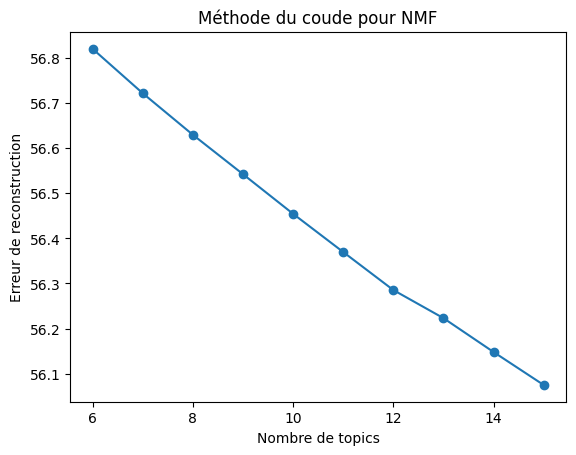

In [10]:
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

ks = range(6, 16)
errors = []

for k in ks:
    nmf = NMF(n_components=k, random_state=42)
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.plot(list(ks), errors, marker='o')
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

# Choix de k = 8

In [11]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=8, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : eau | grand | ciel | arbre | blanc | soleil | ombre | lumière | jour | bois
Topic 2 : monsieur | renée | cher | voix | femme | vrai | vou | homme | monde | abbé
Topic 3 : femme | amour | vie | homme | cœur | pensée | jeune | parole | âme | maîtresse
Topic 4 : sœur | lit | malade | salle | heure | interne | hôpital | médecin | jour | voix
Topic 5 : enfant | mère | petit | fille | père | fils | jeune | mme | bon | maison
Topic 6 : main | oeil | tête | petit | cheveu | bras | regard | corps | robe | pied
Topic 7 : homme | franc | argent | grand | journal | idée | chose | monde | bon | ami
Topic 8 : frère | cirque | exercice | pied | tour | jour | heure | saut | directeur | aîné


In [12]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : eau | ciel | grand | arbre | blanc | soleil | bois | ombre | lumière | noir
Topic 2 : monsieur | renée | cher | voix | femme | vrai | vou | bon | homme | abbé
Topic 3 : femme | amour | vie | homme | cœur | pensée | parole | âme | maîtresse | corps
Topic 4 : heure | jour | matin | chambre | temps | nuit | rue | soir | maison | dîner
Topic 5 : enfant | mère | petit | mme | fils | pauvre | père | cœur | bon | famille
Topic 6 : main | oeil | tête | petit | cheveu | bras | regard | corps | pied | visage
Topic 7 : homme | franc | argent | journal | grand | monde | idée | art | livre | chose
Topic 8 : frère | cirque | exercice | tour | pied | saut | directeur | aîné | clown | chose
Topic 9 : fille | jeune | petit | père | maréchal | grand | mariage | monde | salon | année
Topic 10 : sœur | lit | malade | salle | interne | hôpital | médecin | voix | garde | rideau


In [13]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=12, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : eau | ciel | arbre | blanc | grand | soleil | ombre | bois | lumière | noir
Topic 2 : monsieur | renée | cher | voix | vrai | vou | bon | abbé | maman | monde
Topic 3 : vie | pensée | cœur | mort | amour | âme | parole | chose | idée | jour
Topic 4 : heure | jour | rue | matin | chambre | maison | soir | temps | nuit | dîner
Topic 5 : enfant | mère | petit | fils | mme | pauvre | père | cœur | bon | famille
Topic 6 : femme | amour | homme | maîtresse | mari | amant | toilette | ménage | robe | jeune
Topic 7 : franc | cent | argent | pièce | bon | affaire | sou | fois | jeu | mois
Topic 8 : main | oeil | tête | petit | cheveu | bras | regard | pied | corps | coup
Topic 9 : fille | jeune | père | petit | maréchal | grand | mariage | monde | année | amie
Topic 10 : sœur | lit | malade | salle | interne | hôpital | médecin | voix | garde | rideau
Topic 11 : frère | cirque | exercice | tour | pied | saut | aîné | directeur | clown | chose
Topic 12 : homme | journal | grand | monde

# Chagement de df sur le vectoriseur TF-IDF

In [14]:
vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=4
)

X = vectorizer.fit_transform(df_segments["texte_nettoye"])

X.shape

(3420, 5275)

In [15]:
nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : eau | ciel | grand | arbre | blanc | soleil | ombre | bois | lumière | noir
Topic 2 : monsieur | renée | cher | voix | femme | vrai | vou | bon | abbé | homme
Topic 3 : femme | amour | vie | homme | cœur | pensée | parole | âme | maîtresse | corps
Topic 4 : heure | jour | matin | chambre | temps | rue | nuit | soir | maison | dîner
Topic 5 : enfant | mère | petit | mme | fils | pauvre | père | cœur | bon | famille
Topic 6 : main | oeil | tête | petit | cheveu | bras | regard | corps | pied | visage
Topic 7 : homme | franc | argent | journal | grand | monde | idée | art | livre | nom
Topic 8 : frère | cirque | exercice | tour | pied | saut | aîné | directeur | chose | clown
Topic 9 : fille | jeune | père | petit | maréchal | grand | mariage | monde | salon | année
Topic 10 : sœur | lit | malade | salle | interne | hôpital | médecin | voix | garde | rideau


In [16]:
vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=3
)

X = vectorizer.fit_transform(df_segments["texte_nettoye"])

X.shape

(3420, 6373)

In [17]:
nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : eau | ciel | grand | arbre | blanc | soleil | bois | ombre | lumière | noir
Topic 2 : monsieur | renée | cher | voix | femme | vrai | vou | bon | abbé | homme
Topic 3 : femme | amour | vie | homme | cœur | pensée | parole | âme | maîtresse | corps
Topic 4 : heure | jour | matin | chambre | temps | rue | nuit | soir | maison | bon
Topic 5 : enfant | mère | petit | mme | fils | pauvre | père | cœur | bon | famille
Topic 6 : main | oeil | tête | petit | cheveu | bras | regard | corps | pied | visage
Topic 7 : homme | franc | argent | journal | grand | idée | monde | art | livre | chose
Topic 8 : frère | cirque | exercice | tour | saut | pied | aîné | directeur | clown | chose
Topic 9 : fille | jeune | père | petit | maréchal | grand | mariage | monde | salon | amie
Topic 10 : sœur | lit | malade | salle | interne | hôpital | médecin | voix | garde | rideau


# ajout d'une liste de stop words supplémentaires

In [18]:
stop_sup = {
    "bon", "bien", "tout", "toute", "tous", "toutes",
    "grand", "petit", "autre", "même", "seul",
    "faire", "aller", "venir", "voir", "dire", "savoir",
    "vouloir", "pouvoir", "falloir", "prendre", "mettre",
    "tenir", "donner", "parler", "trouver", "rester",
    "sembler", "penser", "avoir", "être",
    "chose", "fois",
    "monsieur", "madame", "mademoiselle", "mme", "mlle",
    "cher", "vrai", "renée", "croire",
}

def nettoyer_texte_stop(texte):
    doc = nlp(texte)
    tokens = []
    
    for token in doc:
        lemme = token.lemma_.lower()
        
        if (
            not token.is_stop
            and not token.is_punct
            and not token.like_num
            and not token.is_space
            and token.pos_ in {"NOUN", "ADJ", "VERB"}
            and len(lemme) > 2
            and lemme not in stop_sup
        ):
            tokens.append(lemme)
    
    return " ".join(tokens)

In [19]:
df_segments["texte_nettoye"] = df_segments["texte_segment"].apply(nettoyer_texte_stop)

df_segments[["texte_segment", "texte_nettoye"]].head()

,texte_segment,texte_nettoye
0,"— Quarante scudi ? — Oui, signora. — Cela fait...",scudi signorer monnaie cent franc cent franc r...
1,"tout ce qui est beau. À ce mot, l’étrangère re...",beau mot étranger regarder minute fils regard ...
2,d’étrangers à Rome… — Dites-moi : la maison es...,étranger dite maison tranquille bruit heure en...
3,et trempant la plume dans la boue d’un encrier...,tremper plume boue encrier sécher nom faut- re...
4,"Je dois vous prévenir pour les scarpe, les sou...",devoir prévenir scarpe soulier femme chambre f...


In [20]:
vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=3
)

X = vectorizer.fit_transform(df_segments["texte_nettoye"])

X.shape

(3420, 7891)

In [21]:
nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : vie | pensée | mort | cœur | âme | sentir | jour | idée | parole | souffrance
Topic 2 : eau | blanc | ciel | arbre | soleil | noir | lumière | bleu | ombre | bois
Topic 3 : main | oeil | tête | regarder | bras | cheveu | regard | pied | corps | coup
Topic 4 : heure | jour | rue | maison | dîner | porte | chambre | soir | matin | nuit
Topic 5 : fille | jeune | père | maréchal | mariage | monde | bal | année | marier | amie
Topic 6 : enfant | mère | fils | aimer | père | pauvre | embrasser | cœur | famille | maman
Topic 7 : sœur | lit | malade | salle | interne | hôpital | médecin | voix | rideau | garde
Topic 8 : frère | cirque | exercice | saut | tour | pied | directeur | aîné | clown | tonneau
Topic 9 : homme | franc | argent | journal | monde | livre | nom | art | idée | talent
Topic 10 : femme | amour | aimer | homme | maîtresse | amant | mari | amoureux | théâtre | cœur


# technique de topic modeling avec LDA 

In [22]:
texts = [txt.split() for txt in df_segments["texte_nettoye"]]

In [23]:
from gensim.corpora import Dictionary

dictionary = Dictionary(texts)
dictionary.filter_extremes(no_below=3, no_above=0.8)

corpus = [dictionary.doc2bow(text) for text in texts]

In [27]:
from gensim.models import LdaModel

lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=8,
    random_state=42,
    passes=10,
    iterations=100
)

In [28]:
for i, topic in lda.print_topics(num_words=10):
    print(f"Topic {i+1} : {topic}")

Topic 1 : 0.008*"oeil" + 0.007*"blanc" + 0.007*"tête" + 0.007*"femme" + 0.006*"noir" + 0.006*"main" + 0.004*"passer" + 0.004*"milieu" + 0.004*"enfant" + 0.004*"bleu"
Topic 2 : 0.010*"jour" + 0.009*"femme" + 0.008*"fille" + 0.008*"homme" + 0.006*"enfant" + 0.006*"monde" + 0.006*"mère" + 0.006*"vieux" + 0.006*"maison" + 0.005*"temps"
Topic 3 : 0.010*"eau" + 0.008*"ciel" + 0.008*"blanc" + 0.008*"jour" + 0.007*"arbre" + 0.007*"ombre" + 0.006*"soleil" + 0.006*"passer" + 0.006*"bois" + 0.006*"terre"
Topic 4 : 0.018*"femme" + 0.014*"homme" + 0.007*"vie" + 0.007*"amour" + 0.006*"aimer" + 0.006*"enfant" + 0.006*"cœur" + 0.005*"jeune" + 0.005*"monde" + 0.005*"jour"
Topic 5 : 0.010*"jour" + 0.009*"heure" + 0.008*"lit" + 0.008*"passer" + 0.007*"main" + 0.007*"regarder" + 0.006*"temps" + 0.006*"chambre" + 0.006*"homme" + 0.006*"nuit"
Topic 6 : 0.014*"homme" + 0.008*"art" + 0.006*"peintre" + 0.006*"main" + 0.005*"argent" + 0.005*"tableau" + 0.005*"artiste" + 0.005*"tête" + 0.005*"vieux" + 0.004*"bou

# Utilisation de BERTopic pour le topic modeling 

In [29]:
docs = df_segments["texte_segment"].tolist()

In [30]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    stop_words=list(stop_sup),   # ta stoplist complémentaire
    min_df=3
)

topic_model = BERTopic(
    language="multilingual",
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-17 16:12:46,244 - BERTopic - Embedding - Transforming documents to embeddings.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9536.10it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 107/107 [00:39<00:00,  2.70it/s]
2026-04-17 16:13:42,025 - BERTopic - Embedding - Completed ✓
2026-04-17 16:13:42,026 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-17

In [35]:
topic_model.get_topic_info().head(15)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1168,-1_de_la_et_le,"[de, la, et, le, un, les, une, des, dans, qui]",[prestigieux spectacle que celui de ce jeune h...
1,0,1271,0_de_la_et_elle,"[de, la, et, elle, le, des, un, les, une, dans]",[le milieu de son existence. Elle se rappelait...
2,1,407,1_je_est_de_que,"[je, est, de, que, vous, pas, la, un, tu, et]","[pitié de moi, quand je trimais dans la boue, ..."
3,2,198,2_de_et_le_la,"[de, et, le, la, un, des, les, une, dans, en]","[paume, la tamponnant avec de la gaze, la bord..."
4,3,174,3_de_et_la_je,"[de, et, la, je, un, le, mauperin, elle, vous,...","[le bigot, le cafard, s’ allait à la messe… — ..."
5,4,72,4_de_la_et_des,"[de, la, et, des, les, le, une, un, qui, de la]",[la France : elle y entendait Lacordaire. Elle...
6,5,48,5_gianni_nello_de_et,"[gianni, nello, de, et, le, frère, la, des, un...",[découragé aujourd’hui ? » — « Lis-moi un peu ...
7,6,33,6_de_le_la_un,"[de, le, la, un, et, les, des, dans, du, une]",[pour Anatole. Coriolis avait fini son tableau...
8,7,26,7_de_la_le_et,"[de, la, le, et, les, une, elle, un, des, dans]",[contrôle qui faisaient autour tous les lits l...
9,8,23,8_le_de_et_un,"[le, de, et, un, vous, la, des, les, du, livre]",[francs soit convaincu qu’ croit que vous avez...


In [32]:
for topic_id in topic_model.get_topic_info()["Topic"].head(10):
    if topic_id != -1:
        print(f"\nTopic {topic_id}")
        print(topic_model.get_topic(topic_id))


Topic 0
[('je', 0.03837757400768435), ('est', 0.02629555948427586), ('vous', 0.024162336064396776), ('tu', 0.023633885237882665), ('pas', 0.02312567934031842), ('que', 0.02218934467887896), ('me', 0.020702581695980715), ('ça', 0.0198600288366801), ('ai', 0.017967437822000665), ('ne', 0.01746882230956435)]

Topic 1
[('de', 0.026761812723817533), ('des', 0.02675999760088873), ('les', 0.023098801679771942), ('et', 0.021962552643180006), ('un', 0.021311514286471364), ('le', 0.021192538537406908), ('dans', 0.01983474770914027), ('la', 0.0197289846088715), ('du', 0.018107302819898387), ('une', 0.017895252499224492)]

Topic 2
[('elle', 0.04216528382747548), ('de', 0.02248803836458227), ('la', 0.020763061382918037), ('et', 0.020620720937419207), ('avait', 0.017861396826274516), ('qu', 0.01751808802339572), ('son', 0.017296599943050623), ('sa', 0.017232945149611854), ('lui', 0.016732102123153705), ('les', 0.016342042429859108)]

Topic 3
[('la', 0.023381064817255912), ('de', 0.02304246219389791

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

vectorizer_model = CountVectorizer(
    stop_words=list(stop_sup),
    min_df=5,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    language="multilingual",
    vectorizer_model=vectorizer_model,
    nr_topics=10,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

2026-04-17 16:24:30,467 - BERTopic - Embedding - Transforming documents to embeddings.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7249.52it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 107/107 [00:43<00:00,  2.46it/s]
2026-04-17 16:25:20,179 - BERTopic - Embedding - Completed ✓
2026-04-17 16:25:20,190 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-17 16:25:30,067 - BERTopic - Dimensionality - Completed ✓
2026-04-17 16:25:30,070 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-17 16:25:30,190 - BERTopic - Cluster - Completed ✓
2026-04-17 16:25:30,191 - BERTopic - Representation - Extracting topics u

In [39]:
topic_model.get_topic_info().head(15)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1787,-1_de_la_et_le,"[de, la, et, le, un, les, des, une, dans, elle]","[police, calme pour un moment la sous-préfète ..."
1,0,602,0_de_et_je_le,"[de, et, je, le, la, un, est, que, pas, en]",[avec des lisières. — Je n’ai plus de quoi cha...
2,1,277,1_elle_de_la_et,"[elle, de, la, et, le, les, une, sa, dans, qu]",[Puis elle se grondait pour avoir pensé cela e...
3,2,260,2_de_des_et_la,"[de, des, et, la, un, le, les, une, dans, du]","[les bécasses de bois, les sangliers des gouve..."
4,3,159,3_de_la_et_un,"[de, la, et, un, une, le, les, des, dans, elle]","[moment sa tête, encore serrée dans le bonnet ..."
5,4,142,4_de_la_et_les,"[de, la, et, les, des, un, le, une, qui, de la]",[a guère que des rendez-vous et des rencontres...
6,5,80,5_je_vous_de_est,"[je, vous, de, est, que, et, le, la, pas, ne]","[donc... — Vous le sauverez, n’est-ce pas ? — ..."
7,6,51,6_de_la_et_le,"[de, la, et, le, des, un, les, du, une, dans]",[ces critiques qui ne sont que des littérateur...
8,7,43,7_de_et_un_la,"[de, et, un, la, le, des, les, du, dans, une]","[barbillon, brême, le chevenne. voisinait avec..."
9,8,19,8_le_de_et_un,"[le, de, et, un, vous, des, la, du, les, journal]",[francs soit convaincu qu’ croit que vous avez...
